### 🔹 Objectif

Vous allez entraîner votre **premier modèle de classification automatique** pour prédire le **genre littéraire du roman** à partir des **profils lexicaux de personnages**.

Le jeu de données `df_personnages_POLICIER_SENTIMENT_genred` contient :

* 1000 colonnes de fréquences de mots (Bag of Words) ;
* une colonne `"genre"` indiquant si le roman est *policier* ou *sentimental*.

### 🔹 Tâche

1. **Extraire les données**

   * Les variables explicatives `X` correspondent à toutes les colonnes sauf `"genre"`.
   * Les étiquettes `y` correspondent à la colonne `"genre"`.

2. **Diviser les données**

   * Créez un *jeu d’entraînement* (80 %) et un *jeu de test* (20 %) avec `train_test_split`.
   * Option : Utilisez `stratify=y` pour garder la même proportion de genres dans chaque ensemble.

3. **Entraîner un classifieur SVM**

   * Utilisez `LinearSVC` de `scikit-learn`.
   * Fixez `class_weight="balanced"` pour compenser les déséquilibres éventuels.

4. **Évaluer les performances**

   * Prédisez sur le jeu de test.
   * Affichez le `classification_report` et la `ConfusionMatrixDisplay`.
   * Interprétez les résultats : le modèle reconnaît-il mieux un genre que l’autre ? Pourquoi ?
   * Étudier les erreurs du modèle
   * Cross-validation !

5. **Mettre les mains dans le cambouis**
    * A. Tester la sensibilité du modèle - Refaites le `train_test_split` avec différentes proportions (30 %, 40 %) ou différents `random_state`
    * B. Limiter le vocabulaire - Refaites l’expérience avec seulement les 100 mots les plus fréquents (au lieu de 1000). Comparez les résultats.
    * C. Comparer plusieurs modèles SVM - kernel `Polynomial, RBF`
    * D. Filtrer les personnages peu décrits - (Supprimez ceux dont la somme des fréquences est inférieure à un seuil (ex. 0.02).)
    * E. Explorer les coefficients du modèle - Pour un `LinearSVC`, les coefficients indiquent l’importance des mots. Récupérez `clf.coef_` et affichez les 10 mots les plus discriminants pour chaque genre

👉 *Objectif : comprendre le pipeline complet “entraîner → prédire → évaluer”.*


In [7]:
import pandas as pd

In [8]:
df_personnages_POLICIER_SENTIMENT = pd.read_csv("BoW_personnages_Genres.csv", index_col="Unnamed: 0")

In [9]:
df_personnages_POLICIER_SENTIMENT.head(2)

,avoir,dire,voir,faire,vouloir,pouvoir,savoir,aller,aimer,regarder,...,avis,adosser,médecin,défaire,décourager,armer,délaisser,déplaire,creuser,genre
1931_Simenon-Georges_La-Guinguette-a-deux-sous.book --- james,0.069343,0.023723,0.016423,0.031022,0.025547,0.014599,0.023723,0.023723,0.012774,0.041971,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,policier
1931_Simenon-Georges_La-Guinguette-a-deux-sous.book --- maigret,0.059730,0.032755,0.038536,0.009634,0.017341,0.017341,0.017341,0.011561,0.003854,0.040462,...,0.003854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,policier


Best params: {'clf__C': 10}
CV best macro-F1: 0.7594

Classification report (test):

              precision    recall  f1-score   support

    policier      0.750     0.900     0.818        20
 sentimental      0.875     0.700     0.778        20

    accuracy                          0.800        40
   macro avg      0.812     0.800     0.798        40
weighted avg      0.812     0.800     0.798        40



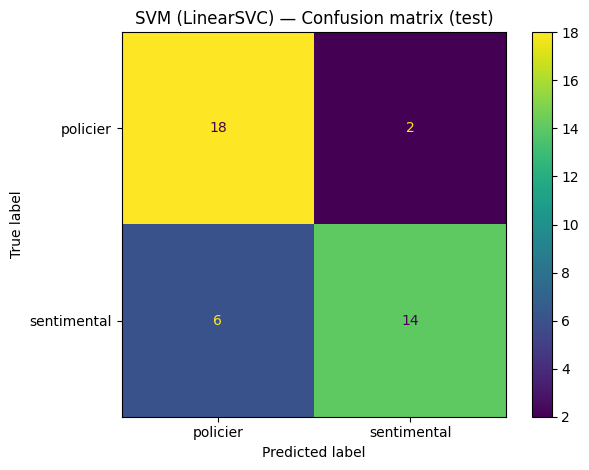

In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) X / y from your dataframe
df = df_personnages_POLICIER_SENTIMENT.copy()
assert "genre" in df.columns, "Missing 'genre' column."

X = df.drop(columns=["genre"]).fillna(0.0).values
y = df["genre"].values

# 2) Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=54
)

# 3) Pipeline + grid-search (LinearSVC)
pipe = Pipeline([
    ("clf", LinearSVC(class_weight="balanced"))
])

param_grid = {
    "clf__C": [0.1, 1, 3, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("CV best macro-F1:", round(gs.best_score_, 4))

# 4) Final evaluation on the held-out test set
y_pred = gs.predict(X_test)
print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred, digits=3))

# 5) Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM (LinearSVC) — Confusion matrix (test)")
plt.tight_layout()
plt.show()
